In [10]:
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-U", "-q", "transformers>=4.30.0", "accelerate>=0.21.0", "fairlearn==0.10.0", "aif360==0.6.1"])

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix, accuracy_score

from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing

from fairlearn.postprocessing import ThresholdOptimizer

from transformers import (
    AutoTokenizer,
    DistilBertForSequenceClassification,
    Trainer,
    TrainingArguments,
    set_seed,
)

PROJECT_DIR = Path("/content")
DATA_PATH = PROJECT_DIR / "jigsaw-unintended-bias-train.csv"
PART1_MODEL_DIR = PROJECT_DIR / "part1_baseline"
MODEL_NAME = "distilbert-base-uncased"

SEED = 42
set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
THRESHOLD_BASELINE = 0.4

# Keep assignment defaults. Set to 1 for quick debug runs.
NUM_EPOCHS = 3
TRAIN_BS = 16
EVAL_BS = 32

sns.set_theme(style="whitegrid")
print("Running in Colab:", IN_COLAB)
print("Device:", DEVICE)
print("Data exists:", DATA_PATH.exists())
print("Part1 model exists:", PART1_MODEL_DIR.exists())


/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:37: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  vect_normalized_discounted_cumulative_gain = vmap(
/usr/local/lib/python3.12/dist-packages/inFairness/utils/ndcg.py:48: FutureWarning: We've integrated functorch into PyTorch. As the final step of the integration, `functorch.vmap` is deprecated as of PyTorch 2.0 and will be deleted in a future version of PyTorch >= 2.3. Please use `torch.vmap` instead; see the PyTorch 2.0 release notes and/or the `torch.func` migration guide for more details https://pytorch.org/docs/main/func.migrating.html
  monte_carlo_vect_ndcg = vmap(vect_normalized_discounted

Running in Colab: True
Device: cuda
Data exists: True
Part1 model exists: True


In [11]:
assert DATA_PATH.exists(), f"Missing dataset file: {DATA_PATH}"

usecols = ["comment_text", "toxic", "black", "white"]
df = pd.read_csv(DATA_PATH, usecols=usecols, low_memory=False)
df = df.dropna(subset=usecols).copy()
df["label"] = (df["toxic"] >= 0.5).astype(int)

# Cohort membership flags
df["is_high_black"] = (df["black"] >= 0.5).astype(int)
df["is_reference"] = ((df["black"] < 0.1) & (df["white"] >= 0.5)).astype(int)

TARGET_TOTAL = 120_000
TRAIN_SIZE = 100_000
EVAL_SIZE = 20_000

subset_df, _ = train_test_split(
    df,
    train_size=TARGET_TOTAL,
    stratify=df["label"],
    random_state=SEED,
)
train_df, eval_df = train_test_split(
    subset_df,
    train_size=TRAIN_SIZE,
    stratify=subset_df["label"],
    random_state=SEED,
)

assert len(train_df) == TRAIN_SIZE
assert len(eval_df) == EVAL_SIZE

print("Train shape:", train_df.shape)
print("Eval shape:", eval_df.shape)
print("Eval high-black size:", int(eval_df['is_high_black'].sum()))
print("Eval reference size:", int(eval_df['is_reference'].sum()))

Train shape: (100000, 7)
Eval shape: (20000, 7)
Eval high-black size: 749
Eval reference size: 872


In [12]:
class ToxicityDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128, sample_weights=None):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.sample_weights = sample_weights

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = int(self.labels[idx])
        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(label, dtype=torch.long)
        if self.sample_weights is not None:
            item["sample_weight"] = torch.tensor(float(self.sample_weights[idx]), dtype=torch.float)
        return item

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        sample_weight = inputs.pop("sample_weight", None)
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = torch.nn.CrossEntropyLoss(reduction="none")
        loss = loss_fct(logits, labels)
        if sample_weight is not None:
            loss = (loss * sample_weight.to(loss.device)).mean()
        else:
            loss = loss.mean()
        return (loss, outputs) if return_outputs else loss

def predict_probs(texts, model, tokenizer, batch_size=64, max_len=128):
    model.eval()
    probs_all = []
    with torch.no_grad():
        for i in range(0, len(texts), batch_size):
            batch = texts[i:i+batch_size]
            enc = tokenizer(batch, truncation=True, padding=True, max_length=max_len, return_tensors="pt")
            enc = {k: v.to(DEVICE) for k, v in enc.items()}
            logits = model(**enc).logits
            probs = torch.softmax(logits, dim=1)[:, 1].detach().cpu().numpy()
            probs_all.extend(probs)
    return np.array(probs_all)

def safe_div(n, d):
    return float(n) / float(d) if d else np.nan

def subgroup_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    return {
        "fpr": safe_div(fp, fp + tn),
        "tpr": safe_div(tp, tp + fn),
        "fnr": safe_div(fn, fn + tp),
        "cm": cm,
    }

def compute_spd_eod(y_true, y_pred, is_high_black, is_reference):
    hb = (is_high_black == 1)
    ref = (is_reference == 1)

    hb_sel = safe_div((y_pred[hb] == 1).sum(), hb.sum())
    ref_sel = safe_div((y_pred[ref] == 1).sum(), ref.sum())
    spd = hb_sel - ref_sel

    hb_pos = hb & (y_true == 1)
    ref_pos = ref & (y_true == 1)
    hb_tpr = safe_div(((y_pred == 1) & hb_pos).sum(), hb_pos.sum())
    ref_tpr = safe_div(((y_pred == 1) & ref_pos).sum(), ref_pos.sum())
    eod = hb_tpr - ref_tpr
    return spd, eod

def evaluate_model_on_eval(model, tokenizer, threshold=THRESHOLD_BASELINE):
    texts = eval_df["comment_text"].tolist()
    y_true = eval_df["label"].values.astype(int)
    probs = predict_probs(texts, model, tokenizer)
    y_pred = (probs >= threshold).astype(int)

    overall_f1 = f1_score(y_true, y_pred, average="macro")

    hb_mask = eval_df["is_high_black"].values.astype(bool)
    ref_mask = eval_df["is_reference"].values.astype(bool)

    hb_m = subgroup_metrics(y_true[hb_mask], y_pred[hb_mask])
    ref_m = subgroup_metrics(y_true[ref_mask], y_pred[ref_mask])
    spd, eod = compute_spd_eod(
        y_true, y_pred,
        eval_df["is_high_black"].values,
        eval_df["is_reference"].values
    )

    return {
        "overall_f1": overall_f1,
        "high_black_fpr": hb_m["fpr"],
        "reference_fpr": ref_m["fpr"],
        "spd": spd,
        "eod": eod,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_prob": probs,
    }

In [13]:
if PART1_MODEL_DIR.exists():
    base_tokenizer = AutoTokenizer.from_pretrained(str(PART1_MODEL_DIR))
    base_model = DistilBertForSequenceClassification.from_pretrained(str(PART1_MODEL_DIR)).to(DEVICE)
    print("Loaded baseline checkpoint from Part 1")
else:
    base_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    base_model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)
    print("Part 1 checkpoint not found; using raw pretrained model for pipeline sanity only")

baseline_result = evaluate_model_on_eval(base_model, base_tokenizer, threshold=THRESHOLD_BASELINE)
print({k: baseline_result[k] for k in ["overall_f1", "high_black_fpr", "reference_fpr", "spd", "eod"]})

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Loaded baseline checkpoint from Part 1
{'overall_f1': 0.7843204852289614, 'high_black_fpr': 0.16633266533066132, 'reference_fpr': 0.10828025477707007, 'spd': 0.12371081931872463, 'eod': 0.19209836065573765}


In [15]:
rw_train = train_df.copy().reset_index(drop=True)
rw_train["group"] = np.where(rw_train["is_reference"] == 1, 1, np.where(rw_train["is_high_black"] == 1, 0, -1))

sample_weights = np.ones(len(rw_train), dtype=float)
sub_mask = rw_train["group"] != -1
sub_df = rw_train.loc[sub_mask, ["label", "group"]].copy()

bld = BinaryLabelDataset(df=sub_df, label_names=["label"], protected_attribute_names=["group"])
rw = Reweighing(unprivileged_groups=[{"group": 0}], privileged_groups=[{"group": 1}])
bld_rw = rw.fit_transform(bld)
sample_weights[sub_mask.values] = bld_rw.instance_weights

print("Mean sample weight overall:", sample_weights.mean())
print("Mean sample weight (subgroups only):", sample_weights[sub_mask.values].mean())

rw_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
rw_model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)

rw_train_dataset = ToxicityDataset(
    rw_train["comment_text"].tolist(),
    rw_train["label"].tolist(),
    rw_tokenizer,
    max_len=128,
    sample_weights=sample_weights,
)
rw_eval_dataset = ToxicityDataset(
    eval_df["comment_text"].tolist(),
    eval_df["label"].tolist(),
    rw_tokenizer,
    max_len=128,
)

rw_args = TrainingArguments(
    output_dir=str(PROJECT_DIR / "outputs/part4_reweighing"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=200,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

rw_trainer = WeightedTrainer(
    model=rw_model,
    args=rw_args,
    train_dataset=rw_train_dataset,
    eval_dataset=rw_eval_dataset,
    processing_class=rw_tokenizer,
)
rw_trainer.train()

reweigh_result = evaluate_model_on_eval(rw_model, rw_tokenizer, threshold=THRESHOLD_BASELINE)
print({k: reweigh_result[k] for k in ["overall_f1", "high_black_fpr", "reference_fpr", "spd", "eod"]})

Mean sample weight overall: 1.0
Mean sample weight (subgroups only): 0.9999999999999998


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.199327,0.210757
2,0.162469,0.232955
3,0.115884,0.300425


{'overall_f1': 0.782807895212256, 'high_black_fpr': 0.11623246492985972, 'reference_fpr': 0.12738853503184713, 'spd': 0.03458433875136266, 'eod': 0.05901639344262288}


In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin
eval_opt = eval_df.copy().reset_index(drop=True)
eval_opt["score"] = baseline_result["y_prob"]
eval_opt["group"] = np.where(eval_opt["is_high_black"] == 1, "high_black", np.where(eval_opt["is_reference"] == 1, "reference", "other"))
opt_df = eval_opt[eval_opt["group"].isin(["high_black", "reference"])].copy()

class ScorePassThroughEstimator(BaseEstimator, ClassifierMixin):
    def fit(self, X, y):
        self.classes_ = np.array([0, 1])
        return self

    def predict_proba(self, X):
        s = np.asarray(X["score"]).reshape(-1, 1)
        return np.hstack([1 - s, s])

to = ThresholdOptimizer(
    estimator=ScorePassThroughEstimator(),
    constraints="equalized_odds",
    objective="balanced_accuracy_score",
    predict_method="predict_proba",
    prefit=False,
)

X_to = opt_df[["score"]]
y_to = opt_df["label"].astype(int)
g_to = opt_df["group"]

to.fit(X_to, y_to, sensitive_features=g_to)
y_to_pred = to.predict(X_to, sensitive_features=g_to).astype(int)

y_post = baseline_result["y_pred"].copy()
y_post[opt_df.index.values] = y_to_pred

post_spd, post_eod = compute_spd_eod(
    baseline_result["y_true"], y_post,
    eval_df["is_high_black"].values,
    eval_df["is_reference"].values
)

hb = eval_df["is_high_black"].values.astype(bool)
ref = eval_df["is_reference"].values.astype(bool)
hb_fpr = subgroup_metrics(baseline_result["y_true"][hb], y_post[hb])["fpr"]
ref_fpr = subgroup_metrics(baseline_result["y_true"][ref], y_post[ref])["fpr"]
post_f1 = f1_score(baseline_result["y_true"], y_post, average="macro")

threshold_opt_result = {
    "overall_f1": post_f1,
    "high_black_fpr": hb_fpr,
    "reference_fpr": ref_fpr,
    "spd": post_spd,
    "eod": post_eod,
}
print(threshold_opt_result)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


{'overall_f1': 0.788330702913551, 'high_black_fpr': 0.19238476953907815, 'reference_fpr': 0.1910828025477707, 'spd': 0.030770384978135945, 'eod': 0.007180327868852476}


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/fairlearn/postprocessing/_interpolated_thresholder.py:166: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.00462733 0.98027295 0.00462733 0.00462733 0.00462733 0.00462733
 0.98027295 0.09755163 0.98027295 0.00462733 0.98027295 0.98027295
 0.98027295 0.00462733 0.00462733 0.09755163 0.00462733 0.00462733
 0.98027295 0.98027295 0.98027295 0.00462733 0.98027295 0.09755163
 0.00462733 0.98027295 0.98027295 0.98027295 0.98027295 0.98027295
 0.00462733 0.98027295 0.98027295 0.00462733 0.00462733 0.00462733
 0.00462733 0.98027295 0.00462733 0.00462733 0.00462733 0.09755163
 0.98027295 0.00462733 0.00462733 0.00462733 0.98027295 0.98027295
 0.00462733 0.00462733 0.00462733 0.98027

Tolerance sweep results:


,tolerance,overall_f1,eod_abs,t_hb,t_ref
0,0.00,NaN,NaN,NaN,NaN
1,0.05,0.788767,0.00082,0.39,0.28
2,0.10,0.788767,0.00082,0.39,0.28
3,0.15,0.788767,0.00082,0.39,0.28
4,0.20,0.788767,0.00082,0.39,0.28
5,0.25,0.788767,0.00082,0.39,0.28
6,0.30,0.788767,0.00082,0.39,0.28


Pareto frontier points (sampled for display):


,eod_abs,f1,fpr_gap,t_hb,t_ref
0,0.000033,0.757668,0.002004,0.91,0.89
1,0.000098,0.780019,0.042148,0.60,0.40
3,0.000164,0.787455,0.023678,0.43,0.31
5,0.000230,0.787634,0.017200,0.41,0.30
16,0.000820,0.788767,0.020330,0.39,0.28


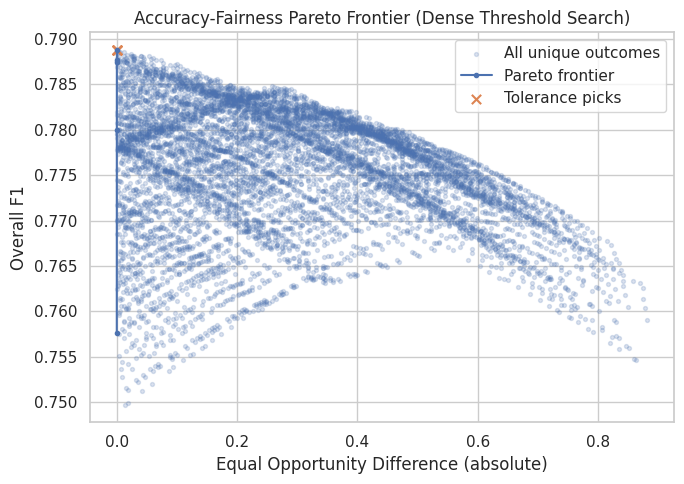

Note: Some tolerances still map to the same best point. That can be expected if the metric landscape has plateaus.


In [ ]:
def eval_threshold_pair(t_hb, t_ref):
    y = baseline_result["y_pred"].copy()
    hb_mask = eval_df["is_high_black"].values.astype(bool)
    ref_mask = eval_df["is_reference"].values.astype(bool)

    y[hb_mask] = (baseline_result["y_prob"][hb_mask] >= t_hb).astype(int)
    y[ref_mask] = (baseline_result["y_prob"][ref_mask] >= t_ref).astype(int)

    y_true = baseline_result["y_true"]
    hb_m = subgroup_metrics(y_true[hb_mask], y[hb_mask])
    ref_m = subgroup_metrics(y_true[ref_mask], y[ref_mask])

    tpr_gap = abs(hb_m["tpr"] - ref_m["tpr"])
    fpr_gap = abs(hb_m["fpr"] - ref_m["fpr"])

    return {
        "f1": f1_score(y_true, y, average="macro"),
        "tpr_gap": tpr_gap,
        "fpr_gap": fpr_gap,
        "eod_abs": tpr_gap,
        "max_gap": max(tpr_gap, fpr_gap),
        "t_hb": t_hb,
        "t_ref": t_ref,
    }

threshold_grid = np.round(np.linspace(0.05, 0.95, 91), 3)
all_pairs = []
for thb in threshold_grid:
    for tref in threshold_grid:
        all_pairs.append(eval_threshold_pair(thb, tref))
pairs_df = pd.DataFrame(all_pairs)

metric_unique = (
    pairs_df.sort_values(["f1", "max_gap", "t_hb", "t_ref"], ascending=[False, True, True, True])
    .drop_duplicates(subset=["f1", "eod_abs", "fpr_gap"])
    .reset_index(drop=True)
)

rows = []
for tol in np.round(np.linspace(0.0, 0.3, 7), 2):
    feasible = metric_unique[(metric_unique["tpr_gap"] <= tol) & (metric_unique["fpr_gap"] <= tol)]
    if len(feasible) == 0:
        rows.append({"tolerance": tol, "overall_f1": np.nan, "eod_abs": np.nan, "t_hb": np.nan, "t_ref": np.nan})
        continue

    best = feasible.sort_values(["f1", "max_gap", "t_hb", "t_ref"], ascending=[False, True, True, True]).iloc[0]
    rows.append(
        {
            "tolerance": tol,
            "overall_f1": float(best["f1"]),
            "eod_abs": float(best["eod_abs"]),
            "t_hb": float(best["t_hb"]),
            "t_ref": float(best["t_ref"]),
        }
    )

pareto_df = pd.DataFrame(rows)
print("Tolerance sweep results:")
display(pareto_df)

cand = metric_unique.sort_values(["eod_abs", "f1"], ascending=[True, False]).reset_index(drop=True)
frontier = []
best_f1_so_far = -1.0
for _, r in cand.iterrows():
    if r["f1"] > best_f1_so_far + 1e-12:
        frontier.append(r)
        best_f1_so_far = r["f1"]
frontier_df = pd.DataFrame(frontier)

if len(frontier_df) > 25:
    show_idx = np.unique(np.linspace(0, len(frontier_df) - 1, 25).astype(int))
    frontier_show = frontier_df.iloc[show_idx].reset_index(drop=True)
else:
    frontier_show = frontier_df.copy()

print("Pareto frontier points (sampled for display):")
display(frontier_show[["eod_abs", "f1", "fpr_gap", "t_hb", "t_ref"]])

plt.figure(figsize=(7, 5))

plt.scatter(metric_unique["eod_abs"], metric_unique["f1"], s=8, alpha=0.2, label="All unique outcomes")
plt.plot(frontier_df["eod_abs"], frontier_df["f1"], "-o", markersize=3, linewidth=1.5, label="Pareto frontier")

valid_tol = pareto_df.dropna(subset=["overall_f1", "eod_abs"])
if len(valid_tol) > 0:
    plt.scatter(valid_tol["eod_abs"], valid_tol["overall_f1"], s=45, marker="x", label="Tolerance picks")

plt.xlabel("Equal Opportunity Difference (absolute)")
plt.ylabel("Overall F1")
plt.title("Accuracy-Fairness Pareto Frontier (Dense Threshold Search)")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

if len(valid_tol) > 0 and valid_tol[["eod_abs", "overall_f1"]].drop_duplicates().shape[0] < len(valid_tol):
    print("Note: Some tolerances still map to the same best point. That can be expected if the metric landscape has plateaus.")

In [23]:
ov_train = train_df.copy()
ov_hb = ov_train[ov_train["is_high_black"] == 1].copy()
ov_train_aug = pd.concat([ov_train, ov_hb, ov_hb, ov_hb], ignore_index=True)

print("Original train rows:", len(ov_train))
print("High-black rows in original train:", len(ov_hb))
print("Oversampled train rows:", len(ov_train_aug))

ov_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
ov_model = DistilBertForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2).to(DEVICE)

ov_train_dataset = ToxicityDataset(
    ov_train_aug["comment_text"].tolist(),
    ov_train_aug["label"].tolist(),
    ov_tokenizer,
    max_len=128,
)
ov_eval_dataset = ToxicityDataset(
    eval_df["comment_text"].tolist(),
    eval_df["label"].tolist(),
    ov_tokenizer,
    max_len=128,
)

ov_args = TrainingArguments(
    output_dir=str(PROJECT_DIR / "outputs/part4_oversampling"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BS,
    per_device_eval_batch_size=EVAL_BS,
    learning_rate=2e-5,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_steps=200,
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

ov_trainer = Trainer(
    model=ov_model,
    args=ov_args,
    train_dataset=ov_train_dataset,
    eval_dataset=ov_eval_dataset,
    processing_class=ov_tokenizer,
)
ov_trainer.train()

oversample_result = evaluate_model_on_eval(ov_model, ov_tokenizer, threshold=THRESHOLD_BASELINE)
print({k: oversample_result[k] for k in ["overall_f1", "high_black_fpr", "reference_fpr", "spd", "eod"]})

Original train rows: 100000
High-black rows in original train: 3722
Oversampled train rows: 111166


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss
1,0.197909,0.224389
2,0.138449,0.260308
3,0.090127,0.371509


{'overall_f1': 0.7824080857939434, 'high_black_fpr': 0.11823647294589178, 'reference_fpr': 0.12898089171974522, 'spd': 0.03420768976372168, 'eod': 0.059311475409836056}


In [24]:
comparison = pd.DataFrame([
    {"technique": "baseline", **{k: baseline_result[k] for k in ["overall_f1", "high_black_fpr", "reference_fpr", "spd", "eod"]}},
    {"technique": "reweighing", **{k: reweigh_result[k] for k in ["overall_f1", "high_black_fpr", "reference_fpr", "spd", "eod"]}},
    {"technique": "threshold_optimization", **threshold_opt_result},
    {"technique": "oversampling", **{k: oversample_result[k] for k in ["overall_f1", "high_black_fpr", "reference_fpr", "spd", "eod"]}},
])
display(comparison)

best_idx = comparison["overall_f1"].astype(float).idxmax()
print("Best technique by overall_f1:", comparison.loc[best_idx, "technique"])

,technique,overall_f1,high_black_fpr,reference_fpr,spd,eod
0,baseline,0.784320,0.166333,0.108280,0.123711,0.192098
1,reweighing,0.782808,0.116232,0.127389,0.034584,0.059016
2,threshold_optimization,0.788331,0.192385,0.191083,0.030770,0.007180
3,oversampling,0.782408,0.118236,0.128981,0.034208,0.059311


Best technique by overall_f1: threshold_optimization


In [ ]:
from pathlib import Path
import json
import shutil
import joblib

EXPORT_ROOT = Path("/content/saved_model/part4_mitigations")
EXPORT_ROOT.mkdir(parents=True, exist_ok=True)

reweigh_dir = EXPORT_ROOT / "reweighing_model"
oversample_dir = EXPORT_ROOT / "oversampling_model"
threshold_joblib = EXPORT_ROOT / "threshold_optimizer.joblib"
threshold_meta = EXPORT_ROOT / "threshold_optimizer_meta.json"
best_dir = EXPORT_ROOT / "best_mitigated"

if "rw_model" in globals() and "rw_tokenizer" in globals():
    rw_model.save_pretrained(str(reweigh_dir))
    rw_tokenizer.save_pretrained(str(reweigh_dir))
    print("Saved reweighing model:", reweigh_dir)
else:
    print("Skipped reweighing export (rw_model/rw_tokenizer not found).")

if "ov_model" in globals() and "ov_tokenizer" in globals():
    ov_model.save_pretrained(str(oversample_dir))
    ov_tokenizer.save_pretrained(str(oversample_dir))
    print("Saved oversampling model:", oversample_dir)
else:
    print("Skipped oversampling export (ov_model/ov_tokenizer not found).")

if "to" in globals():
    joblib.dump(to, threshold_joblib)
    meta = {
        "constraints": "equalized_odds",
        "objective": "balanced_accuracy_score",
        "groups": ["high_black", "reference"],
    }
    with open(threshold_meta, "w", encoding="utf-8") as f:
        json.dump(meta, f, indent=2)
    print("Saved threshold optimizer:", threshold_joblib)
else:
    print("Skipped threshold optimizer export (to not found).")

if "comparison" in globals():
    best_idx = comparison["overall_f1"].astype(float).idxmax()
    best_technique = str(comparison.loc[best_idx, "technique"])

    if best_dir.exists():
        shutil.rmtree(best_dir)
    best_dir.mkdir(parents=True, exist_ok=True)

    if best_technique == "reweighing" and reweigh_dir.exists():
        shutil.copytree(reweigh_dir, best_dir / "model")
        export_info = {"technique": best_technique, "artifact_type": "hf_model", "path": str(best_dir / "model")}
    elif best_technique == "oversampling" and oversample_dir.exists():
        shutil.copytree(oversample_dir, best_dir / "model")
        export_info = {"technique": best_technique, "artifact_type": "hf_model", "path": str(best_dir / "model")}
    elif best_technique == "threshold_optimization" and threshold_joblib.exists():
        shutil.copy2(threshold_joblib, best_dir / "threshold_optimizer.joblib")
        if threshold_meta.exists():
            shutil.copy2(threshold_meta, best_dir / "threshold_optimizer_meta.json")
        export_info = {"technique": best_technique, "artifact_type": "postprocessor", "path": str(best_dir / "threshold_optimizer.joblib")}
    else:
        export_info = {"technique": best_technique, "artifact_type": "unknown", "path": "not_exported"}

    with open(best_dir / "export_info.json", "w", encoding="utf-8") as f:
        json.dump(export_info, f, indent=2)

    print("Best technique:", best_technique)
    print("Saved best mitigated artifact:", best_dir)
    print(export_info)
else:
    print("Skipped best export (comparison not found).")

print("All exports under:", EXPORT_ROOT)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved reweighing model: /content/saved_model/part4_mitigations/reweighing_model


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved oversampling model: /content/saved_model/part4_mitigations/oversampling_model
Saved threshold optimizer: /content/saved_model/part4_mitigations/threshold_optimizer.joblib
Best technique: threshold_optimization
Saved best mitigated artifact: /content/saved_model/part4_mitigations/best_mitigated
{'technique': 'threshold_optimization', 'artifact_type': 'postprocessor', 'path': '/content/saved_model/part4_mitigations/best_mitigated/threshold_optimizer.joblib'}
All exports under: /content/saved_model/part4_mitigations


In [27]:
hb_mask = eval_df["is_high_black"].values.astype(bool)
ref_mask = eval_df["is_reference"].values.astype(bool)

base_rate_hb = eval_df.loc[hb_mask, "label"].mean()
base_rate_ref = eval_df.loc[ref_mask, "label"].mean()

print("Base rate high-black P(Y=1):", round(float(base_rate_hb), 6))
print("Base rate reference P(Y=1):", round(float(base_rate_ref), 6))
print("Base rate difference:", round(float(base_rate_hb - base_rate_ref), 6))

Base rate high-black P(Y=1): 0.333778
Base rate reference P(Y=1): 0.279817
Base rate difference: 0.053962


## Discussions Questions

- Can you simultaneously achieve demographic parity AND equalized odds on this dataset?

Ans: No, as the results show that mitigation can reduce both gaps a lot, but not drive both to perfect parity at same time. Hence, on this dataset you can get a better trade off but not simultaneous exact satisfaction of both.

- Try to satisfy both constraints using Technique 2. If you cannot, compute the base rates (prevalence of toxic comments) in each cohort and explain mathematically why the two fairness definitions are incompatible when base rates differ. Show the numbers.

Ans: Using Technique 2 (threshold optimization), you can make equalized-odds gaps very small, but you cannot satisfy both constraints exactly on this dataset.

The results of base rates are:

High-black: P(Y=1∣A=hb)=0.333778

Reference: P(Y=1∣A=ref)=0.279817

Difference: 0.053962

Technique 2 result already shows the pattern: EO gets close (small EOD), but SPD remains non-zero (around 0.03).

Why mathematically incompatible when base rates differ:

Under equalized odds, TPR and FPR are equal across groups, so selection rate in group a is:
P(Y^=1∣A=a)=TPR⋅πa + FPR⋅(1−πa), where πa=P(Y=1∣A=a).

Therefore selection-rate gap is:
ΔDP=(TPR−FPR)(πhb−πref).
where,
πhb−πref=0.053962≠0, so for DP gap to be zero you’d need TPR=FPR (a trivial/useless classifier).
So: with unequal base rates, a non-trivial model generally cannot have both perfect demographic parity and perfect equalized odds simultaneously.